# Arbitrary Value Imputation
- Definition: Arbitrary Value Imputation is a data preprocessing technique where missing values are replaced with a pre-defined, "arbitrary" constant (such as -1, 99, or 999) that does not occur in the original data. This is done to flag missingness and preserve the total count of samples without deleting rows.

- Purpose: To compare the effects of arbitrary value imputation on feature distribution, variance, and correlation.

- Data Source: The "Titanic Toy" dataset (a subset of the Titanic passenger list).

- Key Steps: Data loading, missing value analysis, manual imputation using Pandas, visualization of distribution shifts (KDE plots), and a professional implementation using Sklearn’s SimpleImputer and ColumnTransformer.

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

## Load the dataset

In [3]:
url = "https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day36-imputing-numerical-data/titanic_toy.csv"

In [4]:
df = pd.read_csv(url)

df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


## Data integrity check.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [6]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

## Feature selection and data splitting.

In [7]:
X =df.drop(columns=['Survived'])
y = df['Survived']

In [8]:
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=7)

In [9]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

**Check missingness in the training set. Re-calculates null percentages specifically for X_train to confirm the split maintained the missing data structure.**

In [10]:
X_train.isnull().mean()

Age       0.199438
Fare      0.047753
Family    0.000000
dtype: float64

## Perform manual arbitrary value imputation.
Creates four new columns. It fills missing Age values with `99` and `-1`, and missing Fare values with `99` and `-1`

In [11]:
X_train["Age_99"] = X_train["Age"].fillna(99)
X_train["Age_minus1"] = X_train["Age"].fillna(-1)

X_train["Fare_99"] = X_train["Fare"].fillna(99)
X_train["Fare_minus1"] = X_train["Fare"].fillna(-1)

Analyze the impact on variance. Compares the `.var()` (variance) of the original columns against the imputed ones.

> Significant changes in variance (e.g., Age variance jumps from ~206 to ~941 when imputed with 99). This proves arbitrary imputation can drastically change the statistical properties of the data.

In [12]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after median imputation: ', X_train['Age_99'].var())
print('Age Variance after mean imputation: ', X_train['Age_minus1'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after median imputation: ', X_train['Fare_99'].var())
print('Fare Variance after mean imputation: ', X_train['Fare_minus1'].var())

Original Age variable variance:  206.7575461859834
Age Variance after median imputation:  941.4383635264065
Age Variance after mean imputation:  312.5909180863703
Original Fare variable variance:  2847.7374433536925
Fare Variance after median imputation:  2908.5395344201606
Fare Variance after mean imputation:  2764.9112562394016


Visualize distribution changes using Kernel Density Estimate (KDE) plots.
 Plots the density curves for original data vs. the two imputed versions for both Age and Fare.

> Plots showing sharp "peaks" at the arbitrary values (-1 or 99). These peaks indicate where the "fake" data was injected.

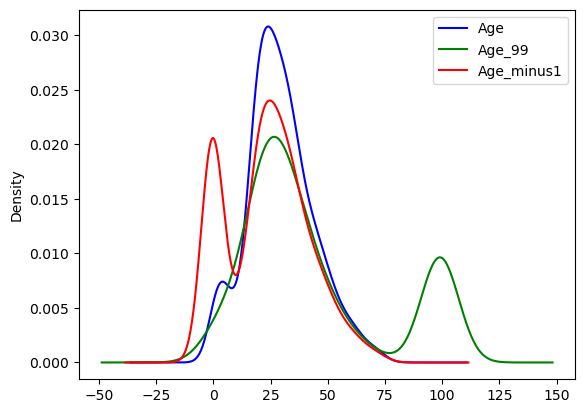

In [13]:
fig = plt.figure()
ax =fig.add_subplot(1,1,1)

#original variable distribution
X_train["Age"].plot(kind = 'kde',ax = ax, color= "blue")
# variable imputed with the median
X_train["Age_99"].plot(kind = 'kde',ax = ax, color= "green")
# variable imputed with the mean
X_train["Age_minus1"].plot(kind = 'kde',ax = ax, color= "red")

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc = 'best')

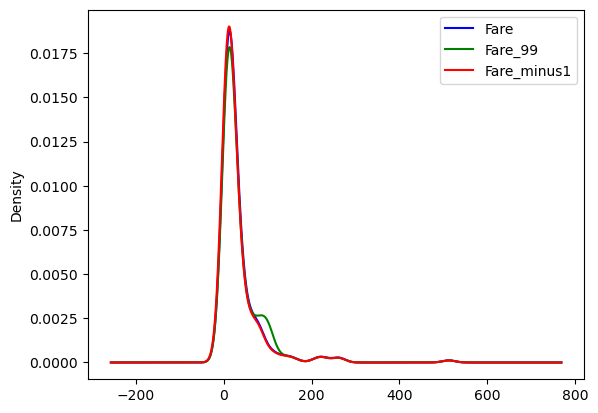

In [14]:
fig = plt.figure()
ax =fig.add_subplot(1,1,1)

#original variable distribution
X_train["Fare"].plot(kind = 'kde',ax = ax, color= "blue")
# variable imputed with the median
X_train["Fare_99"].plot(kind = 'kde',ax = ax, color= "green")
# variable imputed with the mean
X_train["Fare_minus1"].plot(kind = 'kde',ax = ax, color= "red")

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc = 'best')

Analyze the impact on correlations.

In [15]:
X_train.corr()

,Age,Fare,Family,Age_99,Age_minus1,Fare_99,Fare_minus1
Age,1.000000,0.103092,-0.287356,1.000000,1.000000,0.105304,0.095531
Fare,0.103092,1.000000,0.214311,-0.049834,0.140431,1.000000,1.000000
Family,-0.287356,0.214311,1.000000,-0.165369,-0.124926,0.202649,0.209441
Age_99,1.000000,-0.049834,-0.165369,1.000000,-0.317839,-0.047130,-0.048322
Age_minus1,1.000000,0.140431,-0.124926,-0.317839,1.000000,0.140017,0.131823
Fare_99,0.105304,1.000000,0.202649,-0.047130,0.140017,1.000000,0.920033
Fare_minus1,0.095531,1.000000,0.209441,-0.048322,0.131823,0.920033,1.000000


Creates box-and-whisker plots for the original and imputed columns.
> The boxplots for Age_99 will show "99" as a massive outlier, which might affect distance-based models like KNN or Linear Regression.

<Axes: >

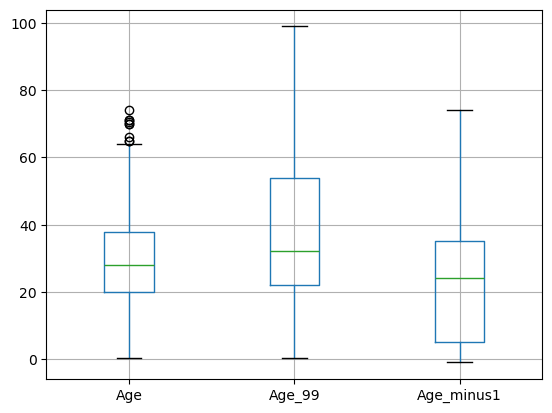

In [16]:
X_train[['Age','Age_99','Age_minus1']].boxplot()

<Axes: >

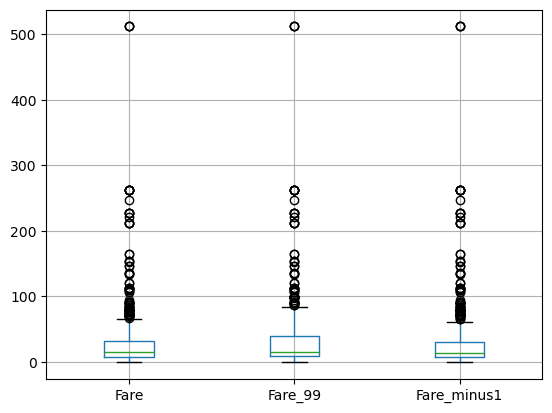

In [17]:
X_train[['Fare','Fare_99','Fare_minus1']].boxplot()

## Implementation using the Scikit-Learn

- Defines two SimpleImputer objects with different fill_value settings.

In [18]:
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=7)

In [19]:
impute1 = SimpleImputer(strategy='constant', fill_value=99)
impute2 = SimpleImputer(strategy="constant", fill_value=999)

- ColumnTransformer applies impute1 to Age and impute2 to Fare while passing through the Family column unchanged.

In [20]:
trf = ColumnTransformer(
    transformers= [
        ("impute1", impute1, ['Age']),
        ("impute2", impute2, ['Fare'])
    ], remainder='passthrough'
)

In [21]:
trf.fit(X_train)

,transformers,"[('impute1', ...), ('impute2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'constant'
,fill_value,99


In [22]:
trf.named_transformers_['impute1'].statistics_

array([99.])

In [23]:
trf.named_transformers_['impute2'].statistics_

array([999.])

In [24]:
X_train=trf.transform(X_train)
X_test=trf.transform(X_test)

In [25]:
X_train

array([[  2.    ,  10.4625,   1.    ],
       [ 99.    ,  15.5   ,   0.    ],
       [ 39.    ,  83.1583,   2.    ],
       ...,
       [ 30.    , 106.425 ,   0.    ],
       [ 99.    ,   7.75  ,   0.    ],
       [ 18.    ,   7.8542,   2.    ]], shape=(712, 3))